In [2]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder #for feature engineering
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error # for␣evaluating ml models

**Dataset**

In [4]:
#loading the dataset
df=pd.read_csv("/content/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
#first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#last 5 rows
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
# checking the data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
df.drop_duplicates(inplace=True)
df_cleaned = df[(df['charges'] < 21000) & (df['bmi'] < 46)]

In [12]:
df.shape

(1337, 7)

In [13]:
df.size

9359

In [17]:
df_cleaned.describe()

,age,bmi,children,charges
count,1068.000000,1068.000000,1068.000000,1068.000000
mean,38.371723,30.091910,1.076779,8159.150438
std,13.943164,5.856569,1.221375,4929.643963
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,25.840000,0.000000,4038.478863
50%,38.000000,29.830000,1.000000,7441.277000
75%,50.000000,33.933750,2.000000,11539.380487
max,64.000000,45.900000,5.000000,20984.093600


In [18]:
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=[0, 25, 40, 60, df_cleaned['age'].max()], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])
df_cleaned.sample(5)

/tmp/ipython-input-3710811165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=[0, 25, 40, 60, df_cleaned['age'].max()], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])


,age,sex,bmi,children,smoker,region,charges,age_group
417,36,female,22.600,2,yes,southwest,18608.26200,Adult
1136,44,female,25.000,1,no,southwest,7623.51800,Middle-aged
313,49,male,35.860,0,no,southeast,8124.40840,Middle-aged
176,38,male,27.835,2,no,northwest,6455.86265,Adult
434,31,male,28.595,1,no,northwest,4243.59005,Adult


One-hot encoding for the 'region' column

In [19]:
df_encoded = pd.get_dummies(df_cleaned, columns=['region'], prefix='region', dtype=int)
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest
1149,42,male,34.100,0,no,5979.73100,Middle-aged,0,0,0,1
1276,22,female,30.400,0,no,2741.94800,Young,1,0,0,0
1255,42,female,37.900,0,no,6474.01300,Middle-aged,0,0,0,1
855,20,female,29.600,0,no,1875.34400,Young,0,0,0,1
995,39,female,23.275,3,no,7986.47525,Adult,1,0,0,0


In [20]:
label_encoder = LabelEncoder()
df_encoded['smoker_encoded'] = label_encoder.fit_transform(df_encoded['smoker'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
15,19,male,24.600,1,no,1837.23700,Young,0,0,0,1,0
1314,30,female,23.655,3,yes,18765.87545,Adult,0,1,0,0,1
371,57,female,22.230,0,no,12029.28670,Middle-aged,1,0,0,0,0
90,21,female,39.490,0,no,2026.97410,Young,0,0,1,0,0
1141,41,female,32.600,3,no,7954.51700,Middle-aged,0,0,0,1,0


In [21]:
df_encoded['sex_encoded'] = label_encoder.fit_transform(df_encoded['sex'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
570,31,female,29.10,0,no,3761.2920,Adult,0,0,0,1,0,0
859,57,male,28.10,0,no,10965.4460,Middle-aged,0,0,0,1,0,1
499,62,female,39.20,0,no,13470.8600,Senior,0,0,0,1,0,0
562,27,male,30.50,0,no,2494.0220,Adult,0,0,0,1,0,1
638,39,male,26.41,0,yes,20149.3229,Adult,1,0,0,0,1,1


In [90]:
from sklearn.model_selection import train_test_split
X = df_encoded[['age', 'smoker_encoded']]
y = df_encoded['charges']



In [79]:
#X = df_encoded[['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']] #'age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded',
#y = df_encoded['charges']

In [91]:

# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [92]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
mlr.fit(x_train, y_train)

Shape of x_train: (747, 2)
Shape of y_train: (747,)


LinearRegression()

In [93]:
print("Estimated model slope: ",mlr.intercept_)
print("Estimated model intercept: ")
list(zip(X, mlr.coef_))

Estimated model slope:  -2110.292699401469
Estimated model intercept: 


[('age', np.float64(245.72041972901766)),
 ('smoker_encoded', np.float64(13035.561501242644))]

In [94]:
#Prediciton on validation set
y_valpred_mlr = mlr.predict(x_val)
print("Prediction for validation set: {}".format(y_valpred_mlr))

#Prediciton on test set
y_testpred_mlr = mlr.predict(x_test)
print("Prediction for test set: {}".format(y_testpred_mlr))

Prediction for validation set: [11158.60996597 12141.49164488  3295.55653464  7227.0832503
  4524.15863328 11895.77122515  7472.80367003 15593.95677669
  3049.83611491  2312.67485572  5015.59947274  5015.59947274
  4278.43821355  3049.83611491  4278.43821355  2804.11569518
 12141.49164488  5752.76073193 10421.44870678  2312.67485572
 12632.93248434 11895.77122515  2804.11569518 10912.88954624
 12141.49164488  3295.55653464  4524.15863328  9192.84660813
 21736.96726992  2312.67485572 15839.67719642  9930.00786732
  6981.36283057  6489.92199111 10175.72828705 17559.72013452
  7472.80367003  5998.48115166  7718.52408976  3295.55653464
  5998.48115166  4769.87905301  2312.67485572 10912.88954624
  9930.00786732  3049.83611491 16576.83845561 11158.60996597
  6735.64241084  4278.43821355  6981.36283057  8701.40576868
  5998.48115166 15348.23635696 10175.72828705 11650.05080542
  7964.24450949 13124.3733238  10912.88954624  8947.1261884
  2558.39527545  2804.11569518  3541.27695437 17068.2792

In [95]:
print("Training set score: {:.4f}".format(mlr.score(x_train, y_train)))
print("Validation set score: {:.4f}".format(mlr.score(x_val, y_val)))
print("Test set score: {:.4f}".format(mlr.score(x_test, y_test)))

Training set score: 0.7211
Validation set score: 0.7155
Test set score: 0.7990


In [96]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_testpred_mlr)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 2023.0387


In [97]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_testpred_mlr)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.7990


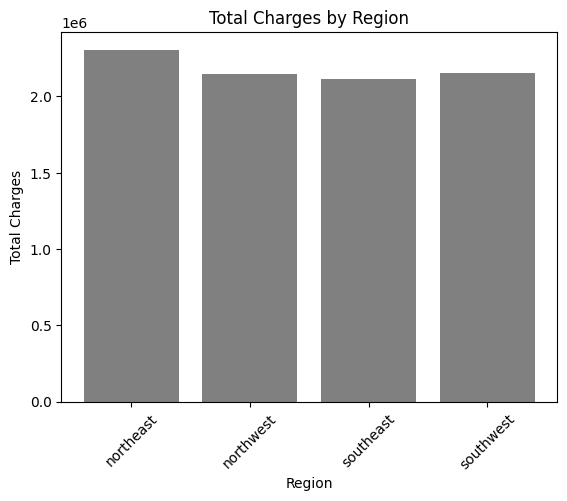

In [98]:
charges_by_region = df_cleaned.groupby('region')['charges'].sum()
plt.bar(charges_by_region.index, charges_by_region.values, color='grey')
plt.xlabel('Region')
plt.ylabel('Total Charges')
plt.title('Total Charges by Region')
plt.xticks(rotation=45)
plt.show()

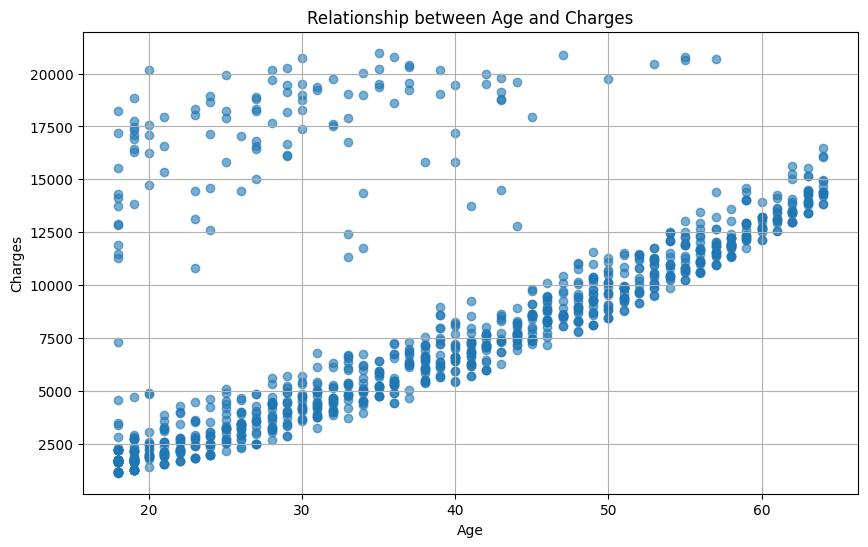

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['age'], df_cleaned['charges'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Relationship between Age and Charges')
plt.grid(True)
plt.show()

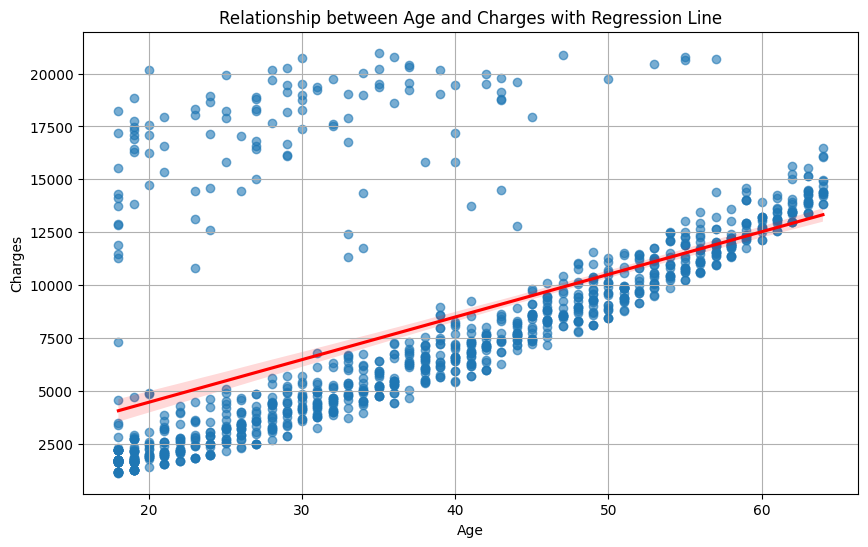

In [101]:
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='charges', data=df_cleaned, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Relationship between Age and Charges with Regression Line')
plt.grid(True)
plt.show()